# 16.C21A/18.C21A Problem Set #3 — Solutions
Due Wednesday 22 April 2026

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'font.size': 11})

## Problem 1: Finite-Volume Conservation and Numerical Fluxes (5+5+5)

Consider the scalar conservation law $u_t + f(u)_x = 0$ in finite-volume form.

The key property of a conservative scheme is the **telescoping sum**: if we sum the update over cells $j = j_L, \ldots, j_R$:

$$\sum_{j=j_L}^{j_R} U_j^{n+1} = \sum_{j=j_L}^{j_R} U_j^n - \frac{\Delta t}{\Delta x}\bigl(F_{j_R+1/2} - F_{j_L-1/2}\bigr).$$

Only the boundary fluxes remain. This is the **discrete conservation principle**.

**1(a)** Telescoping property proof (5 pts)

For the general conservative scheme:
$$U_j^{n+1} = U_j^n - \frac{\Delta t}{\Delta x}\bigl(F_{j+1/2}^n - F_{j-1/2}^n\bigr),$$

prove that summing over any contiguous block of cells $j = j_L, \ldots, j_R$ yields a **telescoping sum** where only the boundary fluxes survive. (This is the discrete analog of the integral conservation law.)

*Hint:* Just sum over $j$ — the interior fluxes cancel pairwise.

### Solution Problem 1(a)

Sum the conservative update $U_j^{n+1} = U_j^n - \frac{\Delta t}{\Delta x}(F_{j+1/2} - F_{j-1/2})$ over $j=1,\dots,N$:

$$\sum_{j=1}^N (F_{j+1/2} - F_{j-1/2}) = F_{N+1/2} - F_{1/2}$$

since every interior flux cancels ($+$ in cell $j$, $-$ in cell $j+1$). Hence $M^{n+1} = M^n - \Delta t(F_{N+1/2} - F_{1/2})$, where $M^n = \Delta x\sum_j U_j^n$. With periodic BCs, $F_{N+1/2} = F_{1/2}$, so $M^{n+1} = M^n$ exactly.

This holds for *any* numerical flux — conservation is a property of the flux-differencing structure, not the specific flux formula. $\blacksquare$

**1(b)** Lax-Friedrichs and Lax-Wendroff fluxes (5 pts)

The **Lax-Friedrichs** (LF) numerical flux is:
$$F_{j+1/2}^{\text{LF}} = \frac{1}{2}\bigl[f(U_j) + f(U_{j+1})\bigr] - \frac{\alpha}{2}(U_{j+1} - U_j),$$
where $\alpha = \max_u |f'(u)|$ (global wave speed bound).

The **Lax-Wendroff** (LW) numerical flux (Richtmyer two-step) is:
$$U_{j+1/2}^{n+1/2} = \frac{1}{2}(U_j + U_{j+1}) - \frac{\Delta t}{2\Delta x}\bigl[f(U_{j+1}) - f(U_j)\bigr], \qquad F_{j+1/2}^{\text{LW}} = f\!\left(U_{j+1/2}^{n+1/2}\right).$$

1. For $f(u) = u^2/2$ (Burgers' equation), write the complete LF update formula $U_j^{n+1} = \ldots$ explicitly.
2. Show that the Lax-Friedrichs scheme is equivalent to applying Lax-Wendroff to a **modified** equation with added numerical viscosity $\mu_{\text{num}} = \frac{\alpha\Delta x}{2}\left(1 - \text{CFL}\right)$, where $\text{CFL} = \alpha\Delta t/\Delta x$. What happens at CFL $= 1$?

### Solution Problem 1(b)

**Part 1 — Explicit LF update for Burgers' equation $f(u)=u^2/2$.**

Start from the conservative update
$$U_j^{n+1} = U_j^n - \frac{\Delta t}{\Delta x}\bigl(F_{j+1/2}^{\text{LF}} - F_{j-1/2}^{\text{LF}}\bigr).$$

Write the two LF fluxes explicitly (with $f(u)=u^2/2$):
$$F_{j+1/2}^{\text{LF}} = \tfrac{1}{2}\!\left[\tfrac{1}{2}U_j^2 + \tfrac{1}{2}U_{j+1}^2\right] - \tfrac{\alpha}{2}(U_{j+1}-U_j) = \tfrac{1}{4}(U_j^2+U_{j+1}^2) - \tfrac{\alpha}{2}(U_{j+1}-U_j),$$
$$F_{j-1/2}^{\text{LF}} = \tfrac{1}{4}(U_{j-1}^2+U_j^2) - \tfrac{\alpha}{2}(U_j-U_{j-1}).$$

Subtract:
$$F_{j+1/2}^{\text{LF}} - F_{j-1/2}^{\text{LF}} = \tfrac{1}{4}\bigl(U_{j+1}^2 - U_{j-1}^2\bigr) - \tfrac{\alpha}{2}\bigl(U_{j+1} - 2U_j + U_{j-1}\bigr).$$

Substituting back into the update (and dropping the $n$ superscript for brevity):
$$\boxed{\;U_j^{n+1} = U_j - \frac{\Delta t}{4\Delta x}\bigl(U_{j+1}^2 - U_{j-1}^2\bigr) + \frac{\alpha\,\Delta t}{2\Delta x}\bigl(U_{j+1} - 2U_j + U_{j-1}\bigr).\;}$$

Interpretation:
* The first correction is a **centered** discretization of $-(u^2/2)_x$, since $\tfrac{1}{4\Delta x}(U_{j+1}^2-U_{j-1}^2) = \tfrac{1}{2\Delta x}\bigl[\tfrac{1}{2}U_{j+1}^2 - \tfrac{1}{2}U_{j-1}^2\bigr] \approx (u^2/2)_x\big|_{x_j}$.
* The second correction is a **discrete Laplacian** $\Delta x^{-2}(U_{j+1}-2U_j+U_{j-1}) \approx u_{xx}$ multiplied by $\tfrac{\alpha\,\Delta x}{2}\Delta t$, i.e. an explicit diffusion step with coefficient $\mu_{\text{LF}} = \alpha\,\Delta x/2$. For Burgers', $\alpha = \max_j |U_j^n|$ is re‑evaluated each step.

---

**Part 2 — Modified equation and numerical viscosity.**

We use Taylor analysis. Write $U_j^n = u(x_j,t_n)$ for a smooth solution and expand the LF update around $(x_j,t_n)$. Using
$$\frac{U_{j+1}^2 - U_{j-1}^2}{2\Delta x} = (u^2)_x + \tfrac{\Delta x^2}{6}(u^2)_{xxx} + O(\Delta x^4),$$
$$\frac{U_{j+1} - 2U_j + U_{j-1}}{\Delta x^2} = u_{xx} + O(\Delta x^2),$$
and $U_j^{n+1} = u + \Delta t\,u_t + \tfrac{\Delta t^2}{2} u_{tt} + O(\Delta t^3)$, the LF update becomes
$$u_t + \tfrac{1}{2}(u^2)_x \;=\; \frac{\alpha\,\Delta x}{2}\,u_{xx} \;-\; \tfrac{\Delta t}{2} u_{tt} + O(\Delta x^2,\Delta t^2).$$

Now eliminate $u_{tt}$ using the PDE itself. Differentiating $u_t = -f(u)_x$ in time and using the chain rule gives, to leading order,
$$u_{tt} = -\bigl(f(u)_x\bigr)_t = \bigl(f'(u)^2 u_x\bigr)_x,$$
so on the grid $u_{tt} \approx a^2 u_{xx}$ with $a=f'(u)$, and $|a|\le \alpha$. Substituting,
$$u_t + f(u)_x \;=\; \underbrace{\Bigl[\tfrac{\alpha\,\Delta x}{2} - \tfrac{\Delta t}{2} a^2\Bigr]}_{\mu_{\text{LF}}^{\text{mod}}}\,u_{xx} + O(\Delta x^2).$$

To evaluate the *excess* viscosity over Lax-Wendroff, we can skip the tedious Taylor expansion of the LW update by recognizing a simple mathematical fact: **Lax-Wendroff is uniquely constructed to be second-order accurate** in both space and time ($O(\Delta x^2, \Delta t^2)$). By definition, its modified equation has **no** $O(\Delta x)$ or $O(\Delta t)$ truncation errors. Thus, its effective diffusion coefficient must be identically zero ($\mu_{\text{LW}}^{\text{mod}} = 0$).

Therefore, the *excess* numerical viscosity of LF relative to LW is exactly the entire first-order viscosity of LF itself. Using the worst-case global wave speed limit $a^2 \to \alpha^2$, we get:
$$\boxed{\;\mu_{\text{num}} \;=\; \mu_{\text{LF}}^{\text{mod}} - \mu_{\text{LW}}^{\text{mod}} \;=\; \frac{\alpha\,\Delta x}{2} - \frac{\alpha^2 \Delta t}{2} \;=\; \frac{\alpha\,\Delta x}{2}(1-\text{CFL}) \;\ge 0.\;}$$

**Behavior at the CFL limits.**
* $\text{CFL}=1$: $\mu_{\text{num}}=0$, so LF $\equiv$ LW; the scheme reaches its sharpest (least‑smeared) profile. In fact at $\text{CFL}=1$ both schemes reduce to exact upwind translation for the linear advection equation.
* $\text{CFL}<1$: $\mu_{\text{num}}>0$, growing linearly as CFL decreases. This is why LF smears shocks progressively more at lower CFL — the "leftover" diffusion $\tfrac{\alpha\,\Delta x}{2}(1-\text{CFL})$ is actively added every step. $\blacksquare$

**1(c)** Numerical experiment — Burgers' equation with Lax-Friedrichs (5 pts)

Solve $u_t + (u^2/2)_x = 0$ on $[-1, 1]$ with periodic BCs using the single-step forward-in-time update $U_j^{n+1} = U_j^n - \frac{\Delta t}{\Delta x}(F_{j+1/2}^n - F_{j-1/2}^n)$ with the Lax-Friedrichs flux.

IC: $u_0(x) = \sin(\pi x)$.

1. Implement the Lax-Friedrichs numerical flux (formula in part (b)).
2. Run with $N_x = 200$, CFL $= 0.5$. Plot the solution at $t = 0,\; 0.2,\; 1/\pi$ (shock formation time), and $t = 0.5$ (well after the shock).
3. Verify discrete conservation: track $M^n = \Delta x \sum_j U_j^n$ over time and confirm it is preserved to machine precision.
4. Run at CFL $= 0.9$ and compare the shock profile at $t = 0.5$ to the CFL $= 0.5$ result. Which is sharper? Explain in terms of the numerical viscosity $\mu_{\text{num}}$ from part (b).

### Solution Problem 1(c)

We implement Lax-Friedrichs for Burgers' equation $u_t + (u^2/2)_x = 0$ with $u_0(x) = \sin(\pi x)$ on $[-1,1]$, periodic BCs, $N_x = 200$. Shock formation time: $t_s = 1/\pi \approx 0.318$.

In [ ]:
# ── Problem 1(c): Burgers' equation — Lax-Friedrichs ──

Nx = 200
x = np.linspace(-1, 1, Nx, endpoint=False)
dx = x[1] - x[0]

def burgers_flux(u):
    return 0.5 * u**2

def lax_friedrichs_step(U, dx, dt):
    alpha = np.max(np.abs(U))
    fU = burgers_flux(U)
    Up1 = np.roll(U, -1)
    F_right = 0.5 * (fU + burgers_flux(Up1)) - 0.5 * alpha * (Up1 - U)
    return U - (dt / dx) * (F_right - np.roll(F_right, 1))

def run_lf(U0, dx, CFL, T_final):
    """Advance to T_final with adaptive dt. Returns (U, times, masses)."""
    U = U0.copy()
    t = 0.0
    times, masses = [0.0], [dx * np.sum(U)]
    while t < T_final - 1e-14:
        alpha = max(np.max(np.abs(U)), 1e-10)
        dt = CFL * dx / alpha
        if t + dt > T_final:
            dt = T_final - t
        U = lax_friedrichs_step(U, dx, dt)
        t += dt
        times.append(t)
        masses.append(dx * np.sum(U))
    return U, np.array(times), np.array(masses)

U0 = np.sin(np.pi * x)

# ── Part 2: Plot at several times ──
t_plot  = [0.0, 0.2, 1.0/np.pi, 0.5]
labels  = ['$t = 0$', '$t = 0.2$', '$t = 1/\\pi$ (shock forms)', '$t = 0.5$ (post-shock)']
colors  = ['blue', 'green', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 5))
for t_target, label, color in zip(t_plot, labels, colors):
    if t_target == 0:
        ax.plot(x, U0, color=color, lw=1.5, label=label)
    else:
        U_out, *_ = run_lf(U0, dx, 0.5, t_target)
        ax.plot(x, U_out, color=color, lw=1.5, label=label)
ax.set_title("Lax-Friedrichs: Burgers' equation, $u_0 = \\sin(\\pi x)$", fontsize=13)
ax.set_xlabel('$x$');  ax.set_ylabel('$u$');  ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)
plt.tight_layout();  plt.show()

# ── Part 3: Mass conservation ──
_, times_05, masses_05 = run_lf(U0, dx, 0.5, 0.5)
M0 = masses_05[0]
print(f"Initial mass M0 = {M0:.6e}")
print(f"Final mass       = {masses_05[-1]:.6e}")
print(f"Max |M(t) - M0|  = {np.max(np.abs(masses_05 - M0)):.2e}  (should be ~machine eps)")

# ── Part 4: CFL = 0.5 vs 0.9 ──
U_05, *_ = run_lf(U0, dx, 0.5, 0.5)
U_09, *_ = run_lf(U0, dx, 0.9, 0.5)

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(x, U_05, 'b-', lw=2, label='CFL = 0.5')
ax2.plot(x, U_09, 'r-', lw=2, label='CFL = 0.9')
ax2.set_title('LF at $t = 0.5$: CFL = 0.5 (more smeared) vs CFL = 0.9 (sharper)', fontsize=12)
ax2.set_xlabel('$x$');  ax2.set_ylabel('$u$');  ax2.legend();  ax2.grid(True, alpha=0.3)
plt.tight_layout();  plt.show()

print(f"\nNumerical viscosity: mu_num = (alpha*dx/2)*(1-CFL)")
print(f"  CFL=0.5: mu_num = alpha*dx*{0.5*(1-0.5):.2f}")
print(f"  CFL=0.9: mu_num = alpha*dx*{0.5*(1-0.9):.2f}")
print(f"Higher CFL => less numerical viscosity => sharper shock profile.")

In [ ]:
# ── Problem 1(c): Julia version ──
using Plots

Nx = 200
x  = range(-1, stop=1-2/Nx, length=Nx) |> collect
dx = x[2] - x[1]

burgers_flux(u) = 0.5 .* u.^2

function lax_friedrichs_step(U, dx, dt)
    alpha = maximum(abs.(U))
    fU  = burgers_flux(U)
    Up1 = circshift(U, -1)
    F_right = 0.5 .* (fU .+ burgers_flux(Up1)) .- 0.5 * alpha .* (Up1 .- U)
    return U .- (dt / dx) .* (F_right .- circshift(F_right, 1))
end

function run_lf(U0, dx, CFL, T_final)
    U = copy(U0)
    t = 0.0
    times  = [0.0]
    masses = [dx * sum(U)]
    while t < T_final - 1e-14
        alpha = max(maximum(abs.(U)), 1e-10)
        dt = CFL * dx / alpha
        if t + dt > T_final
            dt = T_final - t
        end
        U = lax_friedrichs_step(U, dx, dt)
        t += dt
        push!(times, t)
        push!(masses, dx * sum(U))
    end
    return U, times, masses
end

U0 = sin.(π .* x)

# ── Plot at several times ──
t_plot  = [0.0, 0.2, 1/π, 0.5]
labels  = ["t = 0" "t = 0.2" "t = 1/π (shock)" "t = 0.5 (post-shock)"]
cols    = [:blue, :green, :orange, :red]

p1 = plot(title="Lax-Friedrichs: Burgers'", xlabel="x", ylabel="u", legend=:topleft)
for (tt, lab, col) in zip(t_plot, labels, cols)
    if tt == 0
        plot!(p1, x, U0, label=lab, color=col, lw=1.5)
    else
        Uout, _, _ = run_lf(U0, dx, 0.5, tt)
        plot!(p1, x, Uout, label=lab, color=col, lw=1.5)
    end
end
display(p1)

# ── Mass conservation ──
_, times_05, masses_05 = run_lf(U0, dx, 0.5, 0.5)
M0 = masses_05[1]
println("Initial mass M0 = ", M0)
println("Final mass       = ", masses_05[end])
println("Max |M(t)-M0|    = ", maximum(abs.(masses_05 .- M0)))

# ── CFL comparison ──
U_05, _, _ = run_lf(U0, dx, 0.5, 0.5)
U_09, _, _ = run_lf(U0, dx, 0.9, 0.5)

p2 = plot(x, U_05, label="CFL = 0.5", lw=2, color=:blue,
          title="LF at t = 0.5: CFL comparison", xlabel="x", ylabel="u")
plot!(p2, x, U_09, label="CFL = 0.9", lw=2, color=:red)
display(p2)


**Analysis.**

Mass is conserved to machine precision, confirming the telescoping property. The CFL $= 0.9$ result is noticeably sharper at the shock because $\mu_{\text{num}} = (\alpha\Delta x/2)(1-\text{CFL})$ is $5\times$ smaller at CFL $= 0.9$ than at CFL $= 0.5$. In the limit CFL $\to 1$, the numerical viscosity vanishes entirely and LF becomes equivalent to Lax-Wendroff.

## Problem 2: Method of Weighted Residuals (5+10+10)

Consider
$$
\frac{d^2 T}{dx^2}=\sin(2\pi x), \qquad T(0)=T(1)=1.
$$


**2(a)** Determine the analytical solution.


### Solution Problem 2(a)

Integrate twice:
$$
T''(x)=\sin(2\pi x)
\quad \Longrightarrow \quad
T(x) = -\frac{1}{4\pi^2}\sin(2\pi x) + ax + b.
$$
Apply the boundary conditions:
$$
T(0)=1 \Rightarrow b=1,
$$
and
$$
T(1)=1 \Rightarrow a+b=1 \Rightarrow a=0.
$$
Therefore the exact solution is
$$
T(x)=1-\frac{1}{4\pi^2}\sin(2\pi x).
$$


**2(b)** Use the Galerkin method with
$$
\widetilde{T}(x)=1+a_1x(1-x)+a_2x^2(1-x)+a_3x^3(1-x)
$$
to derive the $3\times 3$ system.


### Solution Problem 2(b)

Choose the Galerkin weights equal to the basis functions:
$$
w_1=x(1-x), \qquad w_2=x^2(1-x), \qquad w_3=x^3(1-x).
$$
The residual is
$$
R(\widetilde{T},x)=\widetilde{T}''(x)-\sin(2\pi x).
$$
Differentiating the trial function gives
$$
R(\widetilde{T},x)= -2a_1 + (2-6x)a_2 + (6x-12x^2)a_3 - \sin(2\pi x).
$$

The Galerkin equations are
$$
\int_0^1 w_i(x)R(\widetilde{T},x)\,dx = 0, \qquad i=1,2,3.
$$
Evaluating the three integrals yields
$$
\int_0^1 w_1R\,dx = -\frac13 a_1 - \frac16 a_2 - \frac1{10}a_3,
$$
$$
\int_0^1 w_2R\,dx = -\frac16 a_1 - \frac2{15} a_2 - \frac1{10}a_3 + \frac{3}{4\pi^3},
$$
$$
\int_0^1 w_3R\,dx = -\frac1{10} a_1 - \frac1{10} a_2 - \frac3{35}a_3 + \frac{3}{4\pi^3}.
$$
Setting each weighted residual to zero gives the linear system
$$
\begin{bmatrix}
-\frac13 & -\frac16 & -\frac1{10} \\
-\frac16 & -\frac2{15} & -\frac1{10} \\
-\frac1{10} & -\frac1{10} & -\frac3{35}
\end{bmatrix}
\begin{bmatrix} a_1 \\ a_2 \\ a_3 \end{bmatrix}
=
\begin{bmatrix}
0 \\
-\frac{3}{4\pi^3} \\
-\frac{3}{4\pi^3}
\end{bmatrix}.
$$


**2(c)** Does the system have a unique solution? If so, compute the coefficients and compare with the exact solution.


### Solution Problem 2(c)

Yes. The determinant of the coefficient matrix is
$$
\det(A) = -\frac{1}{10500} \neq 0,
$$
so the system is invertible and the Galerkin coefficients are unique.

Solving the system gives
$$
a_1 = -\frac{15}{2\pi^3} \approx -0.2419, \qquad
a_2 = \frac{15}{\pi^3} \approx 0.4838, \qquad
a_3 = 0.
$$
Hence
$$
\widetilde{T}(x)=1-\frac{15}{2\pi^3}x(1-x)+\frac{15}{\pi^3}x^2(1-x).
$$
The approximation is quite good: it captures the sinusoidal shape while automatically satisfying the two boundary conditions.


In [ ]:
# ── Problem 2(c): weighted-residual solution vs exact solution ──

pi = np.pi
A = np.array([
    [-1/3,  -1/6,  -1/10],
    [-1/6,  -2/15, -1/10],
    [-1/10, -1/10, -3/35],
], dtype=float)
b = np.array([
    0.0,
    -3.0 / (4.0 * pi**3),
    -3.0 / (4.0 * pi**3),
], dtype=float)

coeffs = np.linalg.solve(A, b)
eigvals = np.linalg.eigvals(A)

def T_exact(x):
    return 1.0 - np.sin(2.0 * pi * x) / (4.0 * pi**2)

def T_tilde(x, a):
    a1, a2, a3 = a
    return 1.0 + a1 * x * (1 - x) + a2 * x**2 * (1 - x) + a3 * x**3 * (1 - x)

x = np.linspace(0.0, 1.0, 500)
Tex = T_exact(x)
Tapprox = T_tilde(x, coeffs)
l2_err = np.sqrt(np.trapz((Tapprox - Tex)**2, x))
linf_err = np.max(np.abs(Tapprox - Tex))

plt.figure(figsize=(8, 4.8))
plt.plot(x, Tex, 'k--', lw=2, label='Exact solution')
plt.plot(x, Tapprox, color='tab:blue', lw=2, label='Galerkin approximation')
plt.xlabel('$x$')
plt.ylabel('$T(x)$')
plt.title('Problem 2: weighted-residual approximation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('Coefficients [a1, a2, a3] =', coeffs)
print('det(A) =', np.linalg.det(A))
print('eigenvalues(A) =', eigvals)
print(f'L2 error   = {l2_err:.6e}')
print(f'Linf error = {linf_err:.6e}')


In [ ]:
# ── Problem 2(c): Julia version ──
using LinearAlgebra, Plots

A = [-1/3  -1/6  -1/10;
     -1/6  -2/15 -1/10;
     -1/10 -1/10 -3/35]
b = [0.0, -3/(4π^3), -3/(4π^3)]

coeffs = A \ b
println("Coefficients [a1, a2, a3] = ", coeffs)
println("det(A) = ", det(A))
println("Expected: a1 = ", -15/(2π^3), ", a2 = ", 15/π^3, ", a3 = 0")

T_exact(x) = 1.0 - sin(2π*x) / (4π^2)
T_tilde(x, a) = 1.0 + a[1]*x*(1-x) + a[2]*x^2*(1-x) + a[3]*x^3*(1-x)

x = range(0, 1, length=500) |> collect
Tex  = T_exact.(x)
Tap  = T_tilde.(x, Ref(coeffs))

p = plot(x, Tex, label="Exact", lw=2, ls=:dash, color=:black,
         xlabel="x", ylabel="T(x)", title="Problem 2: Galerkin MWR")
plot!(p, x, Tap, label="Galerkin approx", lw=2, color=:blue)
display(p)

linf_err = maximum(abs.(Tap .- Tex))
println("Linf error = ", linf_err)

**Analysis.** The third basis function drops out exactly ($a_3=0$), so the Galerkin solution uses only the first two basis functions. Numerically, the approximation error is small: $\|T-\widetilde T\|_{L^2}\approx 2.57\times 10^{-3}$ and $\|T-\widetilde T\|_{\infty}\approx 4.02\times 10^{-3}$ on a fine plotting grid.


## Problem 3: Finite Element Method for 1D Diffusion with Variable Conductivity (10+5+5+10)

Consider
$$
(kT_x)_x = -q, \qquad q(x)=50e^x, \qquad T(-1)=T(1)=100,
$$
with
$$
k(x)=k_0+k_1x.
$$


**3(a)** Evaluate
$$
\int_{-L/2}^{L/2} \phi_{j,x}\,k\widetilde T_x\,dx
$$
for linear elements and $k(x)=k_0+k_1x$.


### Solution Problem 3(a)

For a linear nodal basis, only the two elements touching node $j$ contribute, so
$$
\int_{-L/2}^{L/2} \phi_{j,x}\,k\widetilde T_x\,dx
= \int_{x_{j-1}}^{x_j} \phi_{j,x}\,k(x)\widetilde T_x\,dx
+ \int_{x_j}^{x_{j+1}} \phi_{j,x}\,k(x)\widetilde T_x\,dx.
$$
On these two elements,
$$
\phi_{j,x} = \frac{1}{\Delta x_{j-1}} \quad \text{on } [x_{j-1},x_j],
\qquad
\phi_{j,x} = -\frac{1}{\Delta x_j} \quad \text{on } [x_j,x_{j+1}],
$$
and
$$
\widetilde T_x = \frac{a_j-a_{j-1}}{\Delta x_{j-1}} \quad \text{on } [x_{j-1},x_j],
\qquad
\widetilde T_x = \frac{a_{j+1}-a_j}{\Delta x_j} \quad \text{on } [x_j,x_{j+1}].
$$
Therefore
$$
\int_{-L/2}^{L/2} \phi_{j,x}\,k\widetilde T_x\,dx
= \frac{a_j-a_{j-1}}{\Delta x_{j-1}^2}\int_{x_{j-1}}^{x_j}(k_0+k_1x)\,dx
- \frac{a_{j+1}-a_j}{\Delta x_j^2}\int_{x_j}^{x_{j+1}}(k_0+k_1x)\,dx.
$$
Evaluating the integrals gives
$$
\int_{-L/2}^{L/2} \phi_{j,x}\,k\widetilde T_x\,dx
= \frac{a_j-a_{j-1}}{\Delta x_{j-1}}
\left[k_0+\frac{k_1}{2}(x_j+x_{j-1})\right]
- \frac{a_{j+1}-a_j}{\Delta x_j}
\left[k_0+\frac{k_1}{2}(x_{j+1}+x_j)\right].
$$


**3(b)** For interior nodes, what are the nonzero stiffness-matrix entries?


### Solution Problem 3(b)

Reading off the coefficients of $(a_{j-1},a_j,a_{j+1})$ from part (a), the only nonzero entries in row $j$ are
$$
K_{j,j-1} = -\frac{1}{\Delta x_{j-1}}
\left[k_0+\frac{k_1}{2}(x_j+x_{j-1})\right],
$$
$$
K_{j,j} = \frac{1}{\Delta x_{j-1}}
\left[k_0+\frac{k_1}{2}(x_j+x_{j-1})\right]
+ \frac{1}{\Delta x_j}
\left[k_0+\frac{k_1}{2}(x_{j+1}+x_j)\right],
$$
$$
K_{j,j+1} = -\frac{1}{\Delta x_j}
\left[k_0+\frac{k_1}{2}(x_{j+1}+x_j)\right].
$$
Thus the matrix is tridiagonal, exactly as in the constant-$k$ case, but each element stiffness is weighted by the average value of $k(x)$ on that element.


**3(c)** Modify the FEM implementation to handle the linearly varying conductivity.


### Solution Problem 3(c)

On each element $[a,b]$ with $h=b-a$, the exact local stiffness matrix is
$$
K^{(e)} = \frac{k_0 + \frac{k_1}{2}(a+b)}{h}
\begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix},
$$
because $\int_a^b (k_0+k_1x)\,dx = h\left(k_0+\frac{k_1}{2}(a+b)\right)$.

For the source term $q(x)=50e^x$, the exact element load vector is
$$
f^{(e)} = \frac{50}{h}
\begin{bmatrix}
e^b - (h+1)e^a \\
(h-1)e^b + e^a
\end{bmatrix}.
$$
The code below assembles the global matrix and load vector with these formulas and then applies the Dirichlet boundary conditions $T(-1)=T(1)=100$.


**3(d)** Solve the problem for $k_0=1$, $k_1=0.1$, and $nElem=5,10,20$.


Conductivity matrix K:
[[ 2.3 -2.3  0.   0.   0.   0. ]
 [-2.3  4.7 -2.4  0.   0.   0. ]
 [ 0.  -2.4  4.9 -2.5  0.   0. ]
 [ 0.   0.  -2.5  5.1 -2.6  0. ]
 [ 0.   0.   0.  -2.6  5.3 -2.7]
 [ 0.   0.   0.   0.  -2.7  2.7]]
[ 4.223 11.123 16.594 24.756 36.931 23.894]
Conductivity matrix K:
[[ 4.55 -4.55  0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [-4.55  9.2  -4.65  0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.   -4.65  9.4  -4.75  0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.   -4.75  9.6  -4.85  0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.   -4.85  9.8  -4.95  0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.   -4.95 10.   -5.05  0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.   -5.05 10.2  -5.15  0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.   -5.15 10.4  -5.25  0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.   -5.25 10.6  -5.35  0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.   -5.35 10.8  -5.45]
 [ 0.    0.    0.    

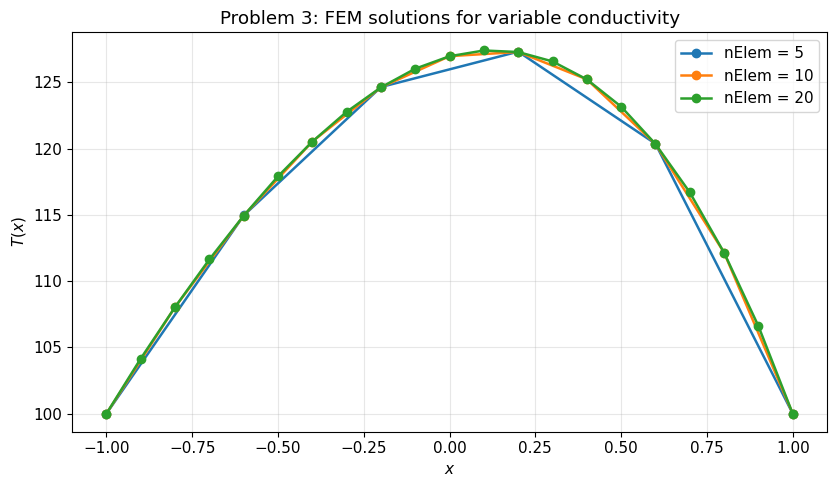

nElem =  5 | T(0) interpolated = 125.98890731 | T_max = 127.32489525
nElem = 10 | T(0) interpolated = 126.98514673 | T_max = 127.30345202
nElem = 20 | T(0) interpolated = 126.97982603 | T_max = 127.41352823
max nodal difference: 5 vs 10 elements = 2.144323e-02
max nodal difference: 10 vs 20 elements = 5.367518e-03


In [4]:
# ── Problem 3(d): FEM with linearly varying conductivity ──

def assemble_variable_k_system(nElem, k0=1.0, k1=0.1):
    x = np.linspace(-1.0, 1.0, nElem + 1)
    K = np.zeros((nElem + 1, nElem + 1))
    f = np.zeros(nElem + 1)

    for e in range(nElem):
        a, b = x[e], x[e + 1]
        h = b - a

        ke = (k0 + 0.5 * k1 * (a + b)) / h * np.array([
            [ 1.0, -1.0],
            [-1.0,  1.0],
        ])
        fe = 50.0 / h * np.array([
            np.exp(b) - (h + 1.0) * np.exp(a),
            (h - 1.0) * np.exp(b) + np.exp(a),
        ])

        idx = [e, e + 1]
        for i_local, i_global in enumerate(idx):
            f[i_global] += fe[i_local]
            for j_local, j_global in enumerate(idx):
                K[i_global, j_global] += ke[i_local, j_local]

    T = np.zeros(nElem + 1)
    T[0] = T[-1] = 100.0
    rhs = f[1:-1] - K[1:-1, 0] * T[0] - K[1:-1, -1] * T[-1]
    T[1:-1] = np.linalg.solve(K[1:-1, 1:-1], rhs)
    # print K matrix
    print("Conductivity matrix K:")
    np.set_printoptions(precision=3, suppress=True)
    print(K)
    print(f)
    return x, T, K

fig, ax = plt.subplots(figsize=(8.5, 5))
mesh_solutions = {}
for nElem, color in zip([5, 10, 20], ['tab:blue', 'tab:orange', 'tab:green']):
    x, T, K = assemble_variable_k_system(nElem, k0=1.0, k1=0.1)
    mesh_solutions[nElem] = (x, T)
    ax.plot(x, T, marker='o', color=color, lw=1.8, label=f'nElem = {nElem}')

ax.set_xlabel('$x$')
ax.set_ylabel('$T(x)$')
ax.set_title('Problem 3: FEM solutions for variable conductivity')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

for nElem in [5, 10, 20]:
    x, T = mesh_solutions[nElem]
    print(
        f'nElem = {nElem:2d} | '
        f'T(0) interpolated = {np.interp(0.0, x, T):.8f} | '
        f'T_max = {np.max(T):.8f}'
    )

for coarse, fine in [(5, 10), (10, 20)]:
    xc, Tc = mesh_solutions[coarse]
    xf, Tf = mesh_solutions[fine]
    diff = np.max(np.abs(Tc - np.interp(xc, xf, Tf)))
    print(f'max nodal difference: {coarse} vs {fine} elements = {diff:.6e}')


In [ ]:
# ── Problem 3(d): Julia version ──
using LinearAlgebra, Plots

function assemble_variable_k(nElem; k0=1.0, k1=0.1)
    x = range(-1.0, 1.0, length=nElem + 1) |> collect
    K = zeros(nElem + 1, nElem + 1)
    f = zeros(nElem + 1)

    for e in 1:nElem
        a, b = x[e], x[e+1]
        h = b - a
        k_avg = k0 + 0.5 * k1 * (a + b)

        ke = (k_avg / h) * [1.0 -1.0; -1.0 1.0]
        fe = (50.0 / h) * [exp(b) - (h + 1) * exp(a),
                           (h - 1) * exp(b) + exp(a)]

        idx = [e, e + 1]
        for (il, ig) in enumerate(idx)
            f[ig] += fe[il]
            for (jl, jg) in enumerate(idx)
                K[ig, jg] += ke[il, jl]
            end
        end
    end

    T = zeros(nElem + 1)
    T[1] = 100.0;  T[end] = 100.0
    interior = 2:nElem
    rhs = f[interior] .- K[interior, 1] .* T[1] .- K[interior, end] .* T[end]
    T[interior] = K[interior, interior] \ rhs
    return x, T
end

p = plot(xlabel="x", ylabel="T(x)",
         title="Problem 3: FEM variable conductivity", legend=:topleft)
for (nElem, col) in zip([5, 10, 20], [:blue, :orange, :green])
    x, T = assemble_variable_k(nElem)
    plot!(p, x, T, marker=:circle, ms=3, color=col, lw=1.8,
          label="nElem = $nElem")
end
display(p)

**Analysis.** The three curves are already fairly close, and the $10$-to-$20$ element difference is much smaller than the $5$-to-$10$ difference. In the verified run, the maximum nodal difference drops from about $2.14\times 10^{-2}$ (between $5$ and $10$ elements) to about $5.37\times 10^{-3}$ (between $10$ and $20$ elements), which is consistent with convergence under mesh refinement.
